# Chemical Name → SMILES Resolver & Structure Generator

**Pipeline:**
1. Load Excel with chemical names
2. Classify names (REGULAR / SEMI-REGULAR / IRREGULAR) with patched rules
3. Preprocess SEMI-REGULAR names (strip trade names, extract aliases)
4. Batch resolve REGULAR + SEMI-REGULAR via PubChem / CIRpy
5. Reroute failures to manual review
6. Generate structure images for resolved compounds
7. Export everything

**Expected:** ~6,760 REGULAR, ~55 SEMI-REGULAR, ~274 truly IRREGULAR

In [2]:
import os, re, time, warnings
import pandas as pd
import numpy as np
from collections import Counter

In [3]:
# List files in the current directory
files = os.listdir()
print("Files in directory:", files)


Files in directory: ['chemical_name_resolver.ipynb', '.ipynb_checkpoints', '1954-King_dataset.csv', '1967_USDA_datasetcsv.csv']


## 1. Install & Upload & Load

In [5]:
import os
import pandas as pd

# ==========================================
# CHOOSE ACTIVE DATASET HERE:
# Set to "1954-King_dataset.csv" OR "1967_USDA_datasetcsv.csv"
# ==========================================
INPUT_FILE = "1954-King_dataset.csv" 

print(f"Active Input File: {INPUT_FILE}")

# Automatically generate a unique output name based on the input
base_name = os.path.splitext(INPUT_FILE)[0]
OUTPUT_FILE = f"resolved_{base_name}.xlsx"
print(f"Dynamic Output Name: {OUTPUT_FILE}")

# Load data
df = pd.read_csv(INPUT_FILE)
print(f"Loaded {len(df)} rows.")

NAME_COL = "Chemical" 
if NAME_COL not in df.columns:
    candidates = [c for c in df.columns if "chem" in c.lower() or "name" in c.lower()]
    if candidates:
        NAME_COL = candidates[0]
        print(f"Auto-detected name column: '{NAME_COL}'")
    else:
        print(f"ERROR: Set NAME_COL manually. Columns: {list(df.columns)}")

df["_name"] = df[NAME_COL].astype(str).str.strip()

Active Input File: 1954-King_dataset.csv
Dynamic Output Name: resolved_1954-King_dataset.xlsx
Loaded 8201 rows.


Uploaded: 1947-King-USDA_Dataset.csv


## 2. Load Data

In [6]:
NAME_COL = "Chemical"  #@param {type:"string"}

df = pd.read_csv(INPUT_FILE)
print(f"Loaded {len(df)} rows.")

if NAME_COL not in df.columns:
    candidates = [c for c in df.columns if "chem" in c.lower() or "name" in c.lower()]
    if candidates:
        NAME_COL = candidates[0]
        print(f"Auto-detected name column: '{NAME_COL}'")
    else:
        print(f"ERROR: Set NAME_COL manually. Columns: {list(df.columns)}")

df["_name"] = df[NAME_COL].astype(str).str.strip()

Loaded 8201 rows.


## 3. Fixed Classifier (Patched Rules)

In [7]:
def analyze_name_v2(name):
    """Patched classifier with fixes for naphthalene, oil sources, etc."""
    tags = []
    raw = str(name).strip()
    low = raw.lower()

    parens = re.findall(r'\(([^)]+)\)', raw)
    parens_text = " ".join(p.lower() for p in parens)

    # --- FORMAT ---
    if parens:
        tags.append("HAS_PARENTHESES")
        for p in parens:
            pl = p.lower().strip()
            # Trade name: single capitalized word in parens, not a chemical substituent
            if re.match(r'^[A-Z][a-z]{3,}$', p.strip()) and not re.search(r'oxy|amino|methyl|ethyl|phenyl|butyl|propyl|chloro|bromo|hydroxy|carboxy', pl):
                tags.append("TRADE_NAME_IN_PARENS")
            if pl.startswith("or "):
                tags.append("ALIAS_IN_PARENS")
            if "mixed" in pl:
                tags.append("MIXED_IN_PARENS")
            if "hydrogenated" in pl:
                tags.append("HYDROGENATED_IN_PARENS")

    if '"' in raw or '\u201c' in raw or '\u201d' in raw:
        tags.append("HAS_QUOTES")
    if "," in raw:
        tags.append("COMMA_SEPARATED")
    if re.match(r'^[A-Za-z][A-Za-z0-9\-]+$', raw) and "," not in raw:
        tags.append("SIMPLE_NAME")

    # --- CHEMICAL CLASS ---
    if re.search(r'acid.*ester', low):
        tags.append("ACID_ESTER_PATTERN")
    if re.search(r'(sodium|potassium|calcium|zinc|copper|iron|\bsalt\b)', low):
        tags.append("SALT_FORM")
    if "ester" in low:
        tags.append("HAS_ESTER")
    if "ether" in low:
        tags.append("HAS_ETHER")
    if re.search(r'\bol\b|alcohol', low):
        tags.append("HAS_ALCOHOL")
    if "acid" in low and "ester" not in low:
        tags.append("ACID_STANDALONE")
    if re.search(r'aldehyde', low):
        tags.append("HAS_ALDEHYDE")
    if re.search(r'ketone|\bone\b', low):
        tags.append("HAS_KETONE")
    if re.search(r'amide|amine|amino', low):
        tags.append("HAS_NITROGEN_FG")
    if re.search(r'\d+[,-]\d+.*di|tri|tetra|penta|hexa|cyclo|methyl|ethyl|propyl|butyl|phenyl', low):
        tags.append("IUPAC_STYLE")
    if re.search(r'\b[dlDL]-|\(\+\)|\(-\)|\([RS]\)|\(E\)|\(Z\)|cis-|trans-|alpha-|beta-', raw):
        tags.append("HAS_STEREOCHEM")
    if re.search(r'\d+,\d+-|\d+-[a-z]', low):
        tags.append("HAS_POSITION_NUMBERS")

    # --- IRREGULARITY FLAGS (PATCHED) ---

    # Adduct / condensate / reaction product
    if re.search(r'adduct|condensat|cooxidation|reaction product|crude product', low):
        tags.append("FLAG_REACTION_PRODUCT")

    # Mixture
    if re.search(r'\bmixed\b|\bmixture\b|\bblend\b', low):
        tags.append("FLAG_MIXTURE")

    # FIXED: Petroleum — use word boundary for 'naphtha' to avoid matching 'naphthalene'
    if re.search(r'\bnaphtha\b|\bpetroleum\b|\bfraction\b|\bsolv\b|\bkerosene\b|\bmineral\b', low):
        tags.append("FLAG_PETROLEUM")

    # Trade names
    if re.search(r'\bamsco\b|\bdowanol\b|\bcellosolve\b|\bcarbitol\b|\bflexalyn\b|\bhercolyn\b|\babalyn\b|\bfreon\b', low):
        tags.append("FLAG_TRADE_NAME")

    # Polymer / resin / wax
    if re.search(r'polymer|polyester|polyethylene|\bresin\b|\bwax\b|\bcellulose\b|\bstarch\b', low):
        tags.append("FLAG_POLYMER_RESIN")

    # FIXED: Oil — exclude "from ___ oil" source descriptions
    if re.search(r'\boil\b', low):
        # Check if it's a source description like "from oil of" or "from pine oil"
        if re.search(r'from\s+.*oil|from\s+oil', low):
            tags.append("OIL_SOURCE_DESCRIPTION")  # Not a flag — informational
        else:
            tags.append("FLAG_OIL")

    # Hydrogenated
    if "hydrogenated" in low:
        tags.append("FLAG_HYDROGENATED")

    # CAS number
    if re.search(r'\d{2,7}-\d{2}-\d', raw):
        tags.append("HAS_CAS_NUMBER")

    # FIXED: Numbered compound — only match "Compound 42" or "#42" style, not structural numbers
    if re.search(r'^\(\d+\)\s|^compound\s+\d|^#\d|^no\.?\s*\d', low):
        tags.append("FLAG_NUMBERED_COMPOUND")

    if len(raw) <= 3:
        tags.append("FLAG_ABBREVIATION")
    if len(raw) > 120:
        tags.append("FLAG_VERY_LONG_NAME")
    if '"' in raw:
        tags.append("HAS_QUOTES")
    if not raw or raw.lower() in ["nan", "n/a", "", "none", "unknown"]:
        tags.append("FLAG_EMPTY")

    if not tags:
        tags.append("UNCLASSIFIED")
    return tags


IRREGULAR_FLAGS = {
    "FLAG_REACTION_PRODUCT", "FLAG_MIXTURE", "FLAG_PETROLEUM",
    "FLAG_POLYMER_RESIN", "FLAG_OIL", "FLAG_ABBREVIATION",
    "FLAG_EMPTY", "FLAG_NUMBERED_COMPOUND", "FLAG_VERY_LONG_NAME",
    "HAS_QUOTES", "MIXED_IN_PARENS",
}
SEMI_FLAGS = {
    "FLAG_TRADE_NAME", "TRADE_NAME_IN_PARENS",
    "FLAG_HYDROGENATED", "ALIAS_IN_PARENS",
}

def classify(tags):
    s = set(tags)
    if s & IRREGULAR_FLAGS:
        return "IRREGULAR"
    elif s & SEMI_FLAGS:
        return "SEMI_REGULAR"
    return "REGULAR"


# Run patched classifier
df["_tags"] = df["_name"].apply(analyze_name_v2)
df["_tags_str"] = df["_tags"].apply(lambda t: " | ".join(sorted(t)))
df["_class"] = df["_tags"].apply(classify)

print("PATCHED CLASSIFICATION:")
print("=" * 50)
for cls, count in df["_class"].value_counts().items():
    pct = count / len(df) * 100
    print(f"  {cls:20s} {count:5d}  ({pct:5.1f}%)")
print(f"  {'TOTAL':20s} {len(df):5d}")

PATCHED CLASSIFICATION:
  REGULAR               8093  ( 98.7%)
  IRREGULAR               80  (  1.0%)
  SEMI_REGULAR            28  (  0.3%)
  TOTAL                 8201


## 4. Name Preprocessor (SEMI-REGULAR → Resolvable)

In [8]:
def preprocess_name(name, tags):
    """
    Generate a list of name variants to try for resolution.
    Returns: list of candidate strings (try in order).
    """
    raw = str(name).strip()
    tag_set = set(tags)
    candidates = []

    # 1. Try raw name first (always)
    candidates.append(raw)

    # 2. Strip parenthetical content → try base name
    base = re.sub(r'\s*\([^)]*\)', '', raw).strip()
    if base and base != raw:
        candidates.append(base)

    # 3. Extract trade name from parens
    if "TRADE_NAME_IN_PARENS" in tag_set:
        trade_names = re.findall(r'\(([A-Z][a-z]{3,})\)', raw)
        candidates.extend(trade_names)

    # 4. Extract alias after "or"
    if "ALIAS_IN_PARENS" in tag_set:
        aliases = re.findall(r'\(or\s+(.+?)\)', raw, re.IGNORECASE)
        candidates.extend([a.strip() for a in aliases])

    # 5. Strip "hydrogenated" → try without
    if "FLAG_HYDROGENATED" in tag_set:
        no_hydro = re.sub(r',?\s*hydrogenated', '', raw, flags=re.IGNORECASE).strip()
        no_hydro = re.sub(r'\(hydrogenated\)', '', no_hydro).strip()
        if no_hydro:
            candidates.append(no_hydro)

    # 6. For "acid, X ester" pattern → try "X acid_root-ate" reconstruction
    acid_ester = re.match(r'(.+?)\s+acid,\s+(.+?)\s+ester', raw, re.IGNORECASE)
    if acid_ester:
        acid_name = acid_ester.group(1).strip()
        ester_group = acid_ester.group(2).strip()
        # Try "ester_group acid_name-ate" (e.g., "methyl abietate")
        candidates.append(f"{ester_group} {acid_name.lower()}ate")
        candidates.append(f"{ester_group} {acid_name.lower()}")

    # 7. For source descriptions "(from oil of X)" → strip entirely
    if "OIL_SOURCE_DESCRIPTION" in tag_set:
        cleaned = re.sub(r'\s*\(from\s+.*?\)', '', raw).strip()
        if cleaned:
            candidates.append(cleaned)

    # Deduplicate while preserving order
    seen = set()
    unique = []
    for c in candidates:
        c_clean = c.strip().rstrip(',').strip()
        if c_clean and c_clean.lower() not in seen:
            seen.add(c_clean.lower())
            unique.append(c_clean)

    return unique


# Test on a few examples
test_names = [
    ("Abietic acid, methyl ester (Abalyn)", ["TRADE_NAME_IN_PARENS", "FLAG_TRADE_NAME", "ACID_ESTER_PATTERN"]),
    ("Acetic acid, glyceryl triester (or triccetin)", ["ALIAS_IN_PARENS", "ACID_ESTER_PATTERN"]),
    ("Anethole (from Pine oil)", ["OIL_SOURCE_DESCRIPTION"]),
    ("Dilactone (liquid),hydrogenated", ["FLAG_HYDROGENATED"]),
]

print("Preprocessor test:")
print("=" * 60)
for name, tags in test_names:
    variants = preprocess_name(name, tags)
    print(f"\n  Input: {name}")
    for i, v in enumerate(variants):
        print(f"    [{i+1}] {v}")

Preprocessor test:

  Input: Abietic acid, methyl ester (Abalyn)
    [1] Abietic acid, methyl ester (Abalyn)
    [2] Abietic acid, methyl ester
    [3] Abalyn
    [4] methyl abieticate
    [5] methyl abietic

  Input: Acetic acid, glyceryl triester (or triccetin)
    [1] Acetic acid, glyceryl triester (or triccetin)
    [2] Acetic acid, glyceryl triester
    [3] triccetin

  Input: Anethole (from Pine oil)
    [1] Anethole (from Pine oil)
    [2] Anethole

  Input: Dilactone (liquid),hydrogenated
    [1] Dilactone (liquid),hydrogenated
    [2] Dilactone,hydrogenated
    [3] Dilactone (liquid)


## 5. PubChem / CIRpy Batch Resolver

In [9]:
import pubchempy as pcp

try:
    import cirpy
    HAS_CIRPY = True
except ImportError:
    HAS_CIRPY = False
    print("[INFO] cirpy not available — using PubChem only")


def resolve_name(name_variants, max_retries=2):
    """
    Try to resolve a list of name variants to a SMILES string.
    Priority: PubChem → CIRpy
    Returns: (smiles, resolved_name, source) or (None, None, 'failed')
    """
    for variant in name_variants:
        # --- PubChem ---
        for attempt in range(max_retries):
            try:
                results = pcp.get_compounds(variant, 'name')
                if results:
                    smiles = results[0].canonical_smiles
                    if smiles:
                        return smiles, variant, "pubchem"
                break  # No results but no error — move to next variant
            except pcp.PubChemHTTPError:
                time.sleep(1)  # Rate limit — wait and retry
            except Exception:
                break

        # --- CIRpy fallback ---
        if HAS_CIRPY:
            try:
                smiles = cirpy.resolve(variant, 'smiles')
                if smiles:
                    return smiles, variant, "cirpy"
            except Exception:
                pass

    return None, None, "failed"


print(f"Resolver ready. PubChem: YES | CIRpy: {'YES' if HAS_CIRPY else 'NO'}")

Resolver ready. PubChem: YES | CIRpy: YES


## 6. Run Batch Resolution

In [10]:
# Only resolve REGULAR and SEMI-REGULAR
resolvable = df[df["_class"].isin(["REGULAR", "SEMI_REGULAR"])].copy()
irregular = df[df["_class"] == "IRREGULAR"].copy()

print(f"Resolving {len(resolvable)} names (REGULAR + SEMI-REGULAR)...")
print(f"Skipping {len(irregular)} IRREGULAR names.")
print(f"\nThis will take approximately {len(resolvable) * 0.5 / 60:.0f}–{len(resolvable) * 1.0 / 60:.0f} minutes.")
print(f"(PubChem rate limit: ~5 requests/sec)\n")

# Progress tracking
smiles_list = []
resolved_name_list = []
source_list = []
n_success = 0
n_fail = 0
batch_start = time.time()

for idx, (df_idx, row) in enumerate(resolvable.iterrows()):
    name = row["_name"]
    tags = row["_tags"]

    # Preprocess to get name variants
    variants = preprocess_name(name, tags)

    # Resolve
    smiles, resolved, source = resolve_name(variants)

    smiles_list.append(smiles)
    resolved_name_list.append(resolved)
    source_list.append(source)

    if smiles:
        n_success += 1
    else:
        n_fail += 1

    # Progress update every 100 rows
    if (idx + 1) % 100 == 0 or idx == 0:
        elapsed = time.time() - batch_start
        rate = (idx + 1) / elapsed if elapsed > 0 else 0
        remaining = (len(resolvable) - idx - 1) / rate / 60 if rate > 0 else 0
        print(f"  [{idx+1:5d}/{len(resolvable)}]  "
              f"OK: {n_success}  FAIL: {n_fail}  "
              f"Rate: {rate:.1f}/sec  "
              f"ETA: {remaining:.1f} min")

    # Rate limiting — be gentle with PubChem
    time.sleep(0.2)

# Add results to resolvable df
resolvable["SMILES"] = smiles_list
resolvable["Resolved_Name"] = resolved_name_list
resolvable["Resolution_Source"] = source_list

elapsed_total = (time.time() - batch_start) / 60
print(f"\n{'='*60}")
print(f"  RESOLUTION COMPLETE in {elapsed_total:.1f} minutes")
print(f"  Success: {n_success}/{len(resolvable)} ({n_success/len(resolvable)*100:.1f}%)")
print(f"  Failed:  {n_fail}/{len(resolvable)} ({n_fail/len(resolvable)*100:.1f}%)")
print(f"{'='*60}")

Resolving 8121 names (REGULAR + SEMI-REGULAR)...
Skipping 80 IRREGULAR names.

This will take approximately 68–135 minutes.
(PubChem rate limit: ~5 requests/sec)

  [    1/8121]  OK: 1  FAIL: 0  Rate: 0.9/sec  ETA: 146.2 min
  [  100/8121]  OK: 71  FAIL: 29  Rate: 1.0/sec  ETA: 133.8 min
  [  200/8121]  OK: 153  FAIL: 47  Rate: 0.9/sec  ETA: 139.9 min
  [  300/8121]  OK: 215  FAIL: 85  Rate: 0.9/sec  ETA: 150.9 min
  [  400/8121]  OK: 284  FAIL: 116  Rate: 0.9/sec  ETA: 147.0 min
  [  500/8121]  OK: 331  FAIL: 169  Rate: 0.9/sec  ETA: 138.6 min
  [  600/8121]  OK: 406  FAIL: 194  Rate: 0.9/sec  ETA: 135.2 min
  [  700/8121]  OK: 488  FAIL: 212  Rate: 0.9/sec  ETA: 134.9 min
  [  800/8121]  OK: 536  FAIL: 264  Rate: 0.9/sec  ETA: 132.0 min
  [  900/8121]  OK: 600  FAIL: 300  Rate: 0.9/sec  ETA: 128.7 min
  [ 1000/8121]  OK: 679  FAIL: 321  Rate: 0.9/sec  ETA: 126.7 min
  [ 1100/8121]  OK: 742  FAIL: 358  Rate: 0.9/sec  ETA: 125.7 min
  [ 1200/8121]  OK: 831  FAIL: 369  Rate: 0.9/sec  ET

## 7. Resolution Summary

In [11]:
# Source breakdown
print("Resolution source breakdown:")
print(resolvable["Resolution_Source"].value_counts().to_string())

# Show some failures
failures = resolvable[resolvable["SMILES"].isna()]
print(f"\nFailed names — sample (first 30):")
print("-" * 60)
for _, row in failures.head(30).iterrows():
    print(f"  {row['_name'][:80]}")
    print(f"    Class: {row['_class']}  Tags: {row['_tags_str'][:60]}")
    print()

Resolution source breakdown:
cirpy     5396
failed    2725

Failed names — sample (first 30):
------------------------------------------------------------
  Abietic acid, 2-(2-hydroxyethoxy)ethyl ester
    Class: REGULAR  Tags: ACID_ESTER_PATTERN | COMMA_SEPARATED | HAS_ESTER | HAS_PAREN

  Abietic acid, tetrahydro-, methyl ester
    Class: REGULAR  Tags: ACID_ESTER_PATTERN | COMMA_SEPARATED | HAS_ESTER | IUPAC_STY

  Abietyl alcohol, thiocyanomethoxy-
    Class: REGULAR  Tags: COMMA_SEPARATED | HAS_ALCOHOL

  Acetaldehyde, bis[2-(methoxymethoxy)ethyl] acetal
    Class: REGULAR  Tags: COMMA_SEPARATED | HAS_ALDEHYDE | HAS_PARENTHESES | IUPAC_STY

  Acetaldehyde, 2-chloroethyl 2, 4, 5-trichloro-phenyl acetal
    Class: REGULAR  Tags: COMMA_SEPARATED | HAS_ALDEHYDE | HAS_POSITION_NUMBERS | IUPA

  Acetaldehyde, dioctyl mercaptal
    Class: REGULAR  Tags: COMMA_SEPARATED | HAS_ALDEHYDE

  Acetaldehyde, bromo-, diallyl acetal
    Class: REGULAR  Tags: COMMA_SEPARATED | HAS_ALDEHYDE

  Aceta

## 8. Merge Results & Classify Final Status

In [12]:
# Add empty SMILES columns to irregular df
irregular["SMILES"] = None
irregular["Resolved_Name"] = None
irregular["Resolution_Source"] = "skipped_irregular"

# Recombine
df_final = pd.concat([resolvable, irregular]).sort_index()

# Final status
def final_status(row):
    if row["_class"] == "IRREGULAR":
        return "IRREGULAR_SKIPPED"
    elif pd.notna(row["SMILES"]):
        return "RESOLVED"
    else:
        return "FAILED_LOOKUP"

df_final["Status"] = df_final.apply(final_status, axis=1)

print("FINAL STATUS:")
print("=" * 50)
for status, count in df_final["Status"].value_counts().items():
    pct = count / len(df_final) * 100
    print(f"  {status:25s} {count:5d}  ({pct:5.1f}%)")
print(f"  {'TOTAL':25s} {len(df_final):5d}")

FINAL STATUS:
  RESOLVED                   5396  ( 65.8%)
  FAILED_LOOKUP              2725  ( 33.2%)
  IRREGULAR_SKIPPED            80  (  1.0%)
  TOTAL                      8201


## 9. Export Results

In [13]:


# Clean export columns
export_cols = [c for c in df_final.columns if not c.startswith("_")]
# Also include classification
df_export = df_final[export_cols].copy()
df_export["Classification"] = df_final["_class"]
df_export["Pattern_Tags"] = df_final["_tags_str"]

with pd.ExcelWriter(OUTPUT_FILE) as writer:
    # All data
    df_export.to_excel(writer, sheet_name="All_Data", index=False)

    # Resolved only
    resolved = df_export[df_export["Status"] == "RESOLVED"]
    resolved.to_excel(writer, sheet_name="Resolved", index=False)

    # Failed lookups (for retry / manual)
    failed = df_export[df_export["Status"] == "FAILED_LOOKUP"]
    failed.to_excel(writer, sheet_name="Failed_Lookup", index=False)

    # Irregular (skipped)
    irreg_out = df_export[df_export["Status"] == "IRREGULAR_SKIPPED"]
    irreg_out.to_excel(writer, sheet_name="Irregular", index=False)

print(f"Exported: {OUTPUT_FILE}")
print(f"  Sheet 'All_Data':       {len(df_export)} rows")
print(f"  Sheet 'Resolved':       {len(resolved)} rows (have SMILES)")
print(f"  Sheet 'Failed_Lookup':  {len(failed)} rows (need manual review)")
print(f"  Sheet 'Irregular':      {len(irreg_out)} rows (skipped)")


Exported: resolved_1954-King_dataset.xlsx
  Sheet 'All_Data':       8201 rows
  Sheet 'Resolved':       5396 rows (have SMILES)
  Sheet 'Failed_Lookup':  2725 rows (need manual review)
  Sheet 'Irregular':      80 rows (skipped)


## 10. Quick Structure Preview (First 12 Resolved)

In [15]:
!pip install rdkit

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 36.2 MB 1.8 MB/s eta 0:00:01


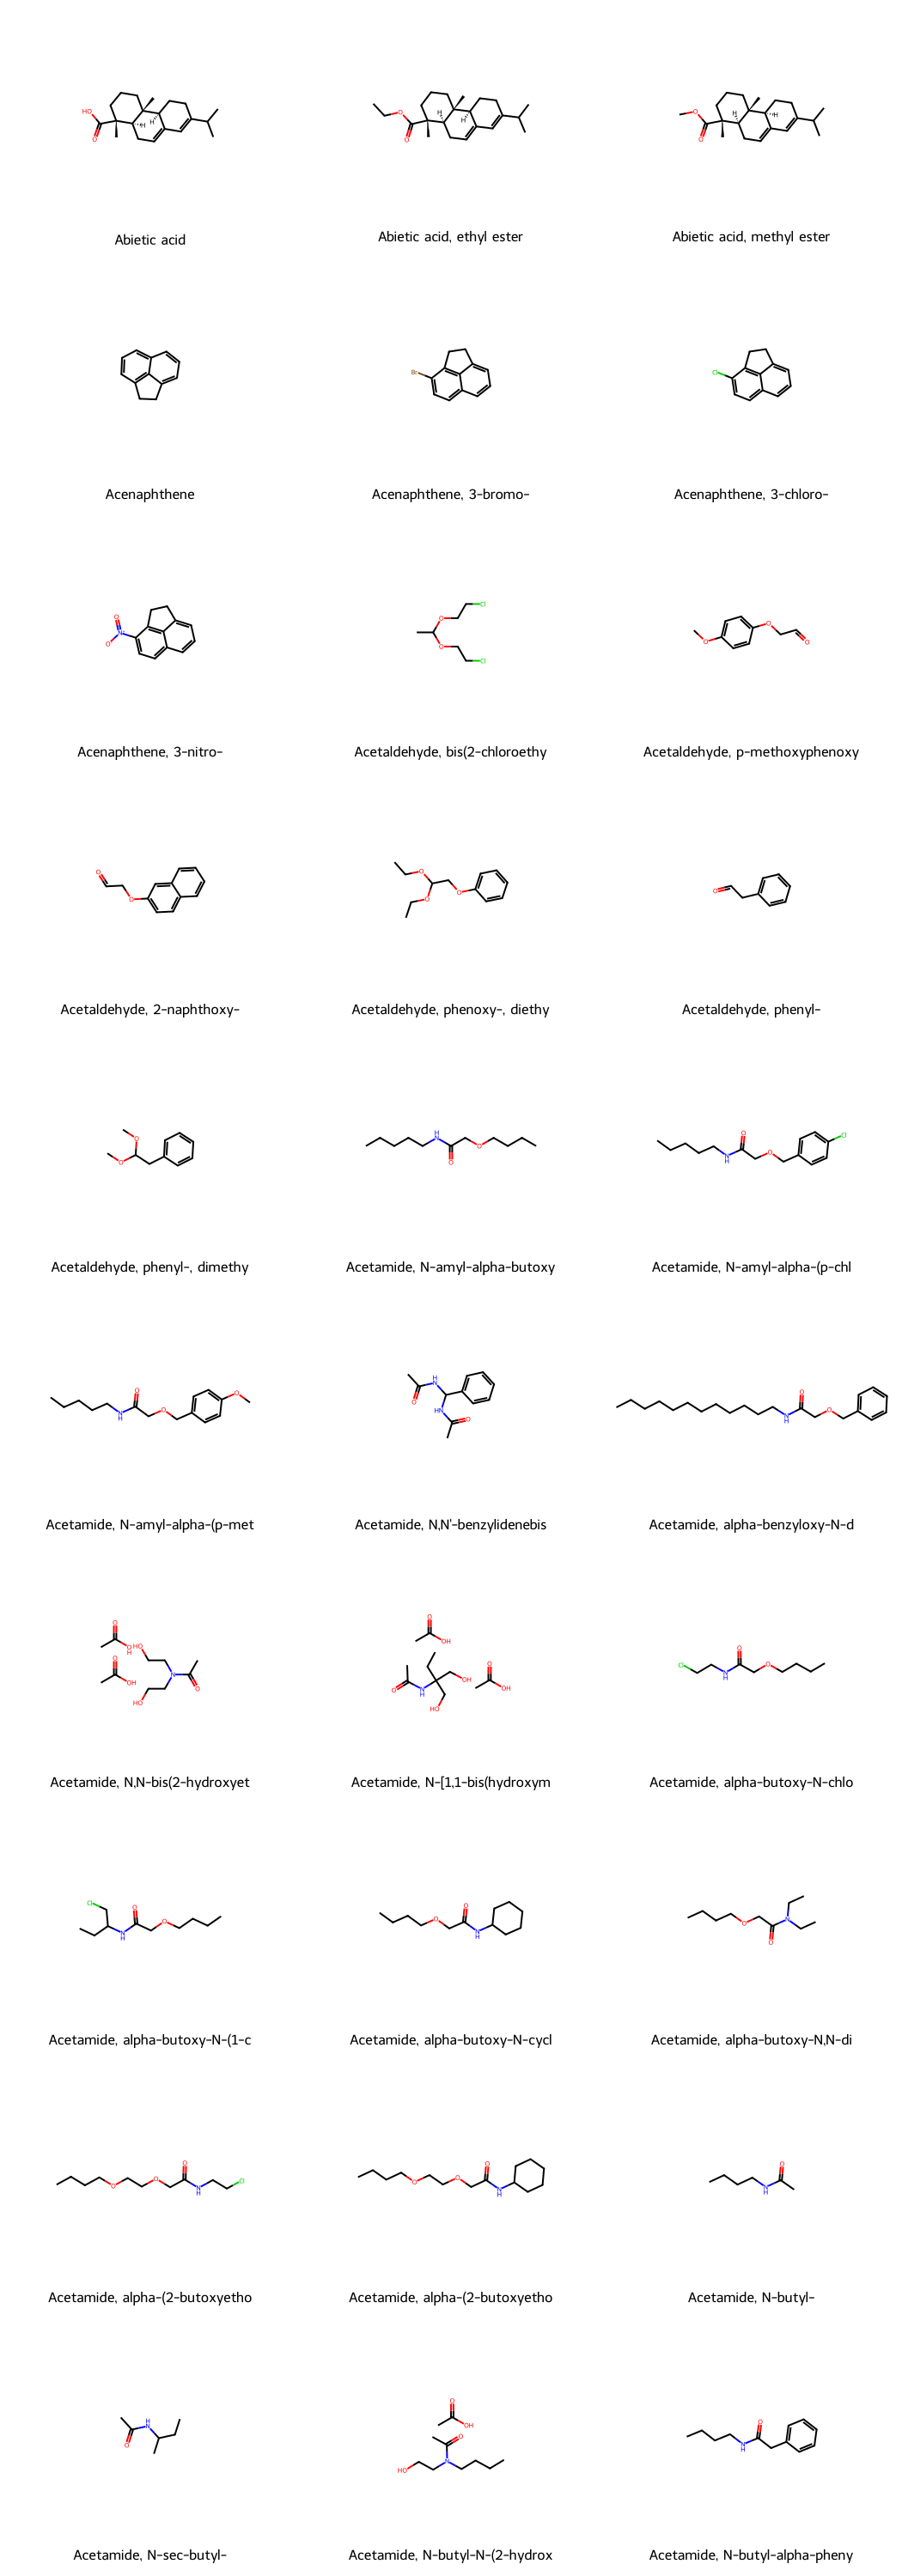


Showing 30 resolved structures.


In [14]:
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from IPython.display import display

resolved_df = df_final[df_final["SMILES"].notna()].head(30)

mols = []
legends = []
for _, row in resolved_df.iterrows():
    mol = Chem.MolFromSmiles(row["SMILES"])
    if mol:
        AllChem.Compute2DCoords(mol)
        mols.append(mol)
        legends.append(f"{row['_name'][:30]}")

if mols:
    grid_img = Draw.MolsToGridImage(
        mols, molsPerRow=3, subImgSize=(350, 300),
        legends=legends
    )
    display(grid_img)
    print(f"\nShowing {len(mols)} resolved structures.")
else:
    print("No structures to display.")

In [18]:
import base64
import io
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit import RDLogger

# 1. Quiet RDKit console warnings and errors
RDLogger.DisableLog('rdApp.*')

# 2. Load the resolved data
df_final = pd.read_excel("resolved_1954-King_dataset.xlsx", sheet_name="All_Data")

if "_name" not in df_final.columns and "Chemical" in df_final.columns:
    df_final["_name"] = df_final["Chemical"]

def generate_clean_html_report(dataframe, output_html="resolved_structures.html"):
    resolved_df = dataframe[dataframe["SMILES"].notna()].copy()
    total_resolved = len(resolved_df)
    
    if total_resolved == 0:
        print("No resolved structures to export.")
        return
        
    print(f"Generating HTML report for {total_resolved} resolved compounds...")
    
    html_content = """<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Resolved 1954 Data Chemical Structures Report</title>
<style>
    body { font-family: Arial, sans-serif; background-color: #f8f9fa; margin: 20px; color: #333; }
    h1 { text-align: center; color: #2c3e50; margin-bottom: 5px; }
    .subtitle { text-align: center; color: #7f8c8d; margin-bottom: 30px; font-size: 14px; }
    .grid-container { display: grid; grid-template-columns: repeat(auto-fill, minmax(220px, 1fr)); gap: 20px; }
    .card { background: white; border: 1px solid #e2e8f0; border-radius: 8px; padding: 15px; text-align: center; box-shadow: 0 4px 6px rgba(0,0,0,0.05); transition: transform 0.2s; }
    .card:hover { transform: translateY(-3px); box-shadow: 0 6px 12px rgba(0,0,0,0.1); }
    .card img { max-width: 100%; height: auto; border-bottom: 1px solid #f1f5f9; padding-bottom: 10px; }
    .placeholder-img { height: 220px; display: flex; align-items: center; justify-content: center; background-color: #f1f5f9; color: #94a3b8; font-size: 11px; border-bottom: 1px solid #e2e8f0; margin-bottom: 10px; border-radius: 4px; }
    .card h4 { font-size: 13px; margin: 10px 0 5px 0; word-break: break-word; color: #2c3e50; }
    .card p { font-size: 10px; color: #64748b; word-break: break-all; margin: 0; line-height: 1.4; }
</style>
</head>
<body>
    <h1>Resolved 1954 Data Chemical Structures Report</h1>
    <p class="subtitle">Total resolved compounds: """ + str(total_resolved) + """</p>
    <div class="grid-container">
"""
    
    for idx, row in resolved_df.iterrows():
        mol = Chem.MolFromSmiles(row["SMILES"])
        
        # If the molecule can be successfully parsed, generate its image
        if mol:
            img = Draw.MolToImage(mol, size=(220, 220))
            buffered = io.BytesIO()
            img.save(buffered, format="PNG")
            img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
            img_element = f'<img src="data:image/png;base64,{img_str}" alt="{row["_name"]}">'
        else:
            # Fallback placeholder if RDKit cannot parse/kekulize the SMILES string
            img_element = '<div class="placeholder-img">Structure Drawing Unavailable</div>'
            
        html_content += f"""
        <div class="card">
            {img_element}
            <h4>{row['_name']}</h4>
            <p><strong>SMILES:</strong> {row['SMILES']}</p>
        </div>"""
        
    html_content += """
    </div>
</body>
</html>
"""
    with open(output_html, "w", encoding="utf-8") as f:
        f.write(html_content)
        
    print(f"HTML report successfully saved to: {output_html}")

generate_clean_html_report(df_final)

Generating HTML report for 5396 resolved compounds...
HTML report successfully saved to: resolved_structures.html
